In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

In [31]:
df = pd.read_csv('superstore_clean_data.csv')

In [32]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

In [40]:
df.columns.tolist()

['Row ID',
 'Order ID',
 'Order Date',
 'Ship Date',
 'Ship Mode',
 'Customer ID',
 'Customer Name',
 'Segment',
 'Country',
 'City',
 'State',
 'Postal Code',
 'Region',
 'Product ID',
 'Category',
 'Sub-Category',
 'Product Name',
 'Sales',
 'Order Year',
 'Order Month']

In [34]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [43]:
def indian_rupee_format(x, pos):
    
    if x >= 10000000:  # Crores
        return f'₹{x/10000000:.1f}Cr'
    elif x >= 100000:  # Lakhs
        return f'₹{x/100000:.1f}L'
    else:
        return f'₹{x:,.0f}'  # Normal numbers with commas

# Apply this formatter to all charts
formatter = ticker.FuncFormatter(indian_rupee_format)

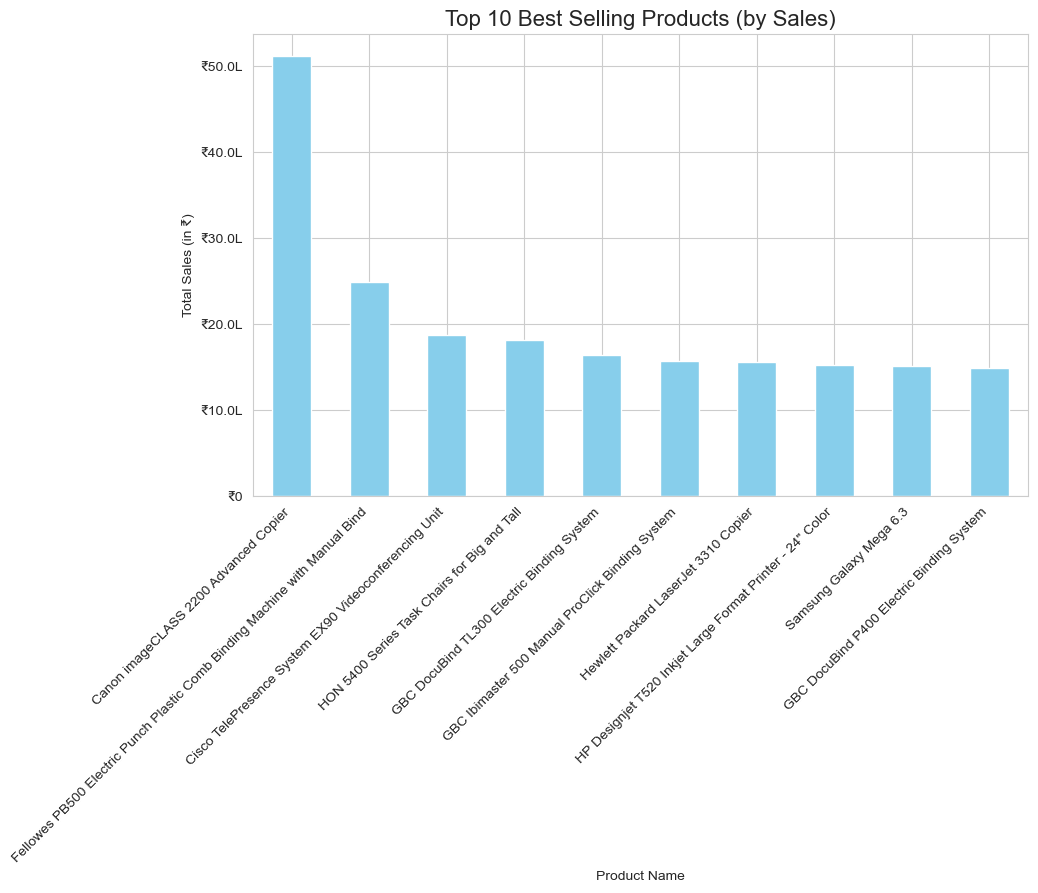

In [49]:
# CHART 1: TOP 10 BEST SELLING PRODUCTS (Bar Chart)
# Question: Which products drive the highest sales
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

fig, ax = plt.subplots()  # Create a figure with axis
top_products.plot(kind='bar', color='skyblue', ax=ax)
ax.yaxis.set_major_formatter(formatter)  # APPLY THE FIX HERE
plt.title('Top 10 Best Selling Products (by Sales)', fontsize=16)
plt.xlabel('Product Name')
plt.ylabel('Total Sales (in ₹)')
plt.xticks(rotation=45, ha='right')
plt.show()

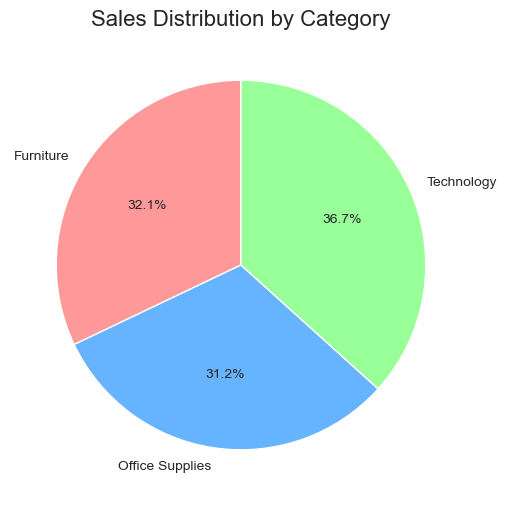

In [50]:
# finding the total sales by category wise
category_sales = df.groupby('Category')['Sales'].sum()

fig, ax = plt.subplots()
category_sales.plot(kind='pie', autopct='%1.1f%%', startangle=90, colors=['#ff9999','#66b3ff','#99ff99'], ax=ax)
plt.title('Sales Distribution by Category', fontsize=16)
plt.ylabel('')
plt.show()

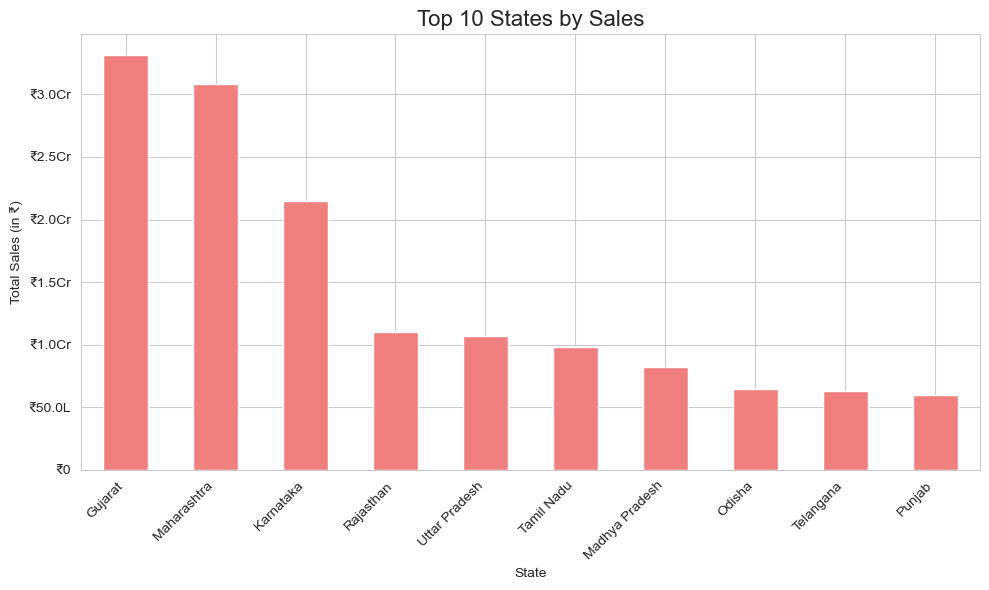

In [55]:
# top 10 States by Sales 
top_states = df.groupby('State')['Sales'].sum().sort_values(ascending=False).head(10)

fig, ax = plt.subplots()
top_states.plot(kind='bar', color='lightcoral', ax=ax)
ax.yaxis.set_major_formatter(formatter)  
plt.title('Top 10 States by Sales', fontsize=16)
plt.xlabel('State')
plt.ylabel('Total Sales (in ₹)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


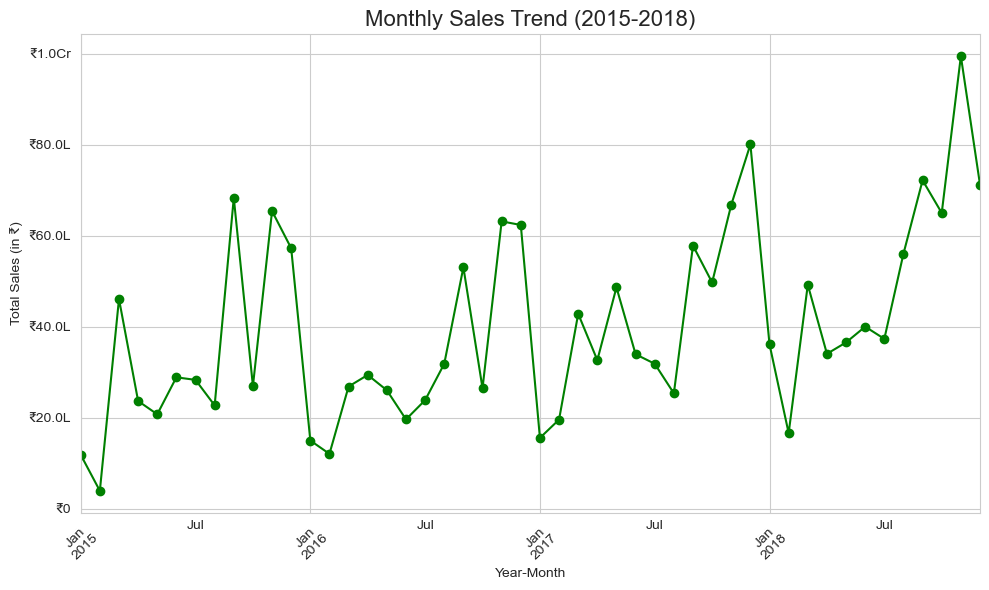

In [69]:
# monthly Sales Trend 
df['Year_Month'] = df['Order Date'].dt.to_period('M')
monthly_sales = df.groupby('Year_Month')['Sales'].sum()

fig, ax = plt.subplots()
monthly_sales.plot(kind='line', marker='o', color='green', ax=ax)
ax.yaxis.set_major_formatter(formatter)  # APPLY THE FIX HERE
plt.title('Monthly Sales Trend (2015-2018)', fontsize=16)
plt.xlabel('Year-Month')
plt.ylabel('Total Sales (in ₹)')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

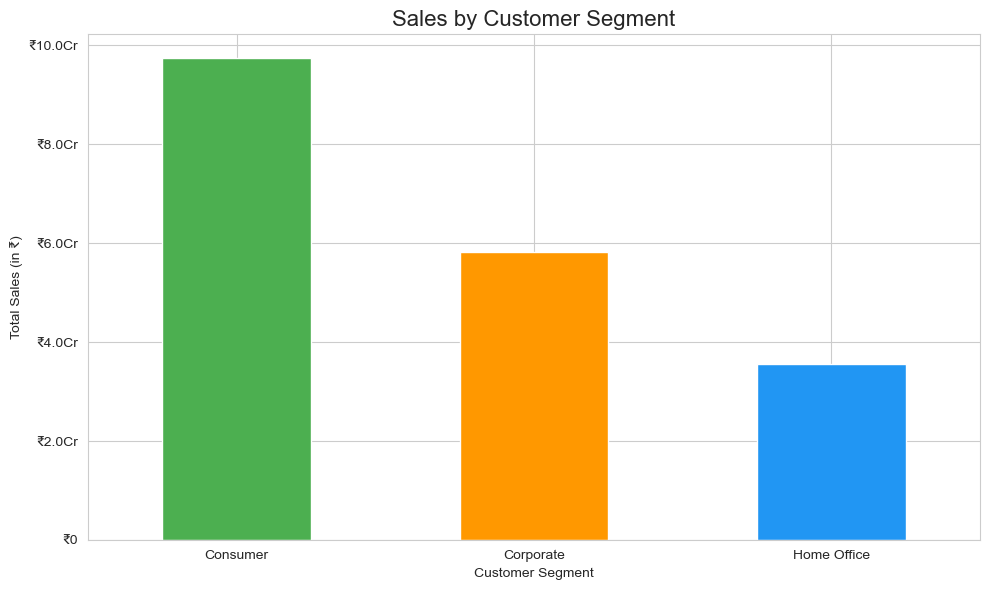

In [70]:
# Sales By customer Segment 
segment_sales = df.groupby('Segment')['Sales'].sum().sort_values(ascending=False)

fig, ax = plt.subplots()
segment_sales.plot(kind='bar', color=['#4CAF50', '#FF9800', '#2196F3'], ax=ax)
ax.yaxis.set_major_formatter(formatter)  
plt.title('Sales by Customer Segment', fontsize=16)
plt.xlabel('Customer Segment')
plt.ylabel('Total Sales (in ₹)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

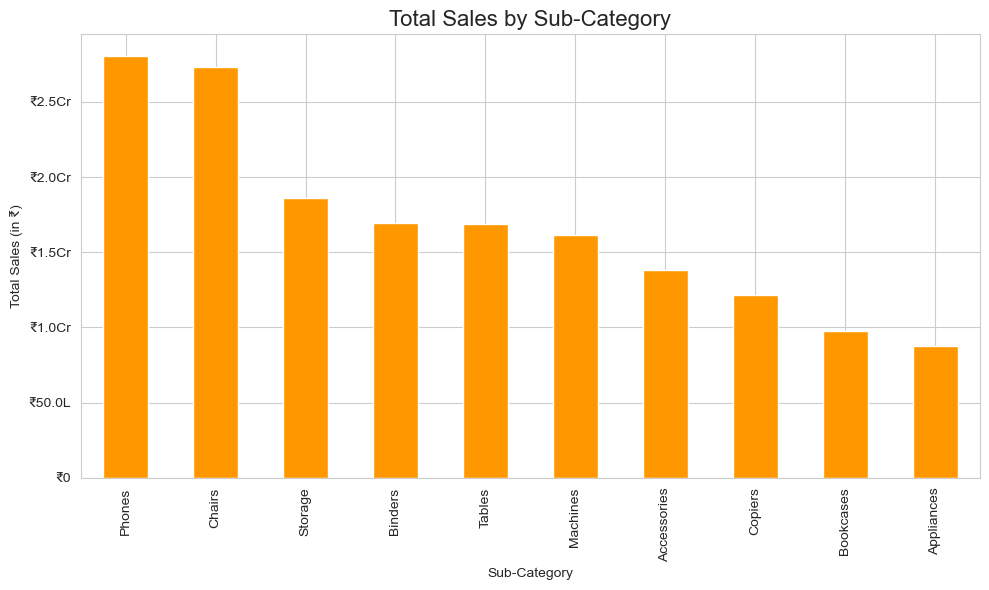

In [77]:
# Top 10 sub categories by Sales 

subcategory_sales = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending = False).head(10)


fig, ax = plt.subplots()
subcategory_sales.plot(kind = 'bar',color = '#FF9800',ax = ax)
ax.yaxis.set_major_formatter(formatter)
plt.title("Total Sales by Sub-Category", fontsize = 16)
plt.xlabel("Sub-Category")
plt.ylabel("Total Sales (in ₹)")
plt.tight_layout()
plt.show()

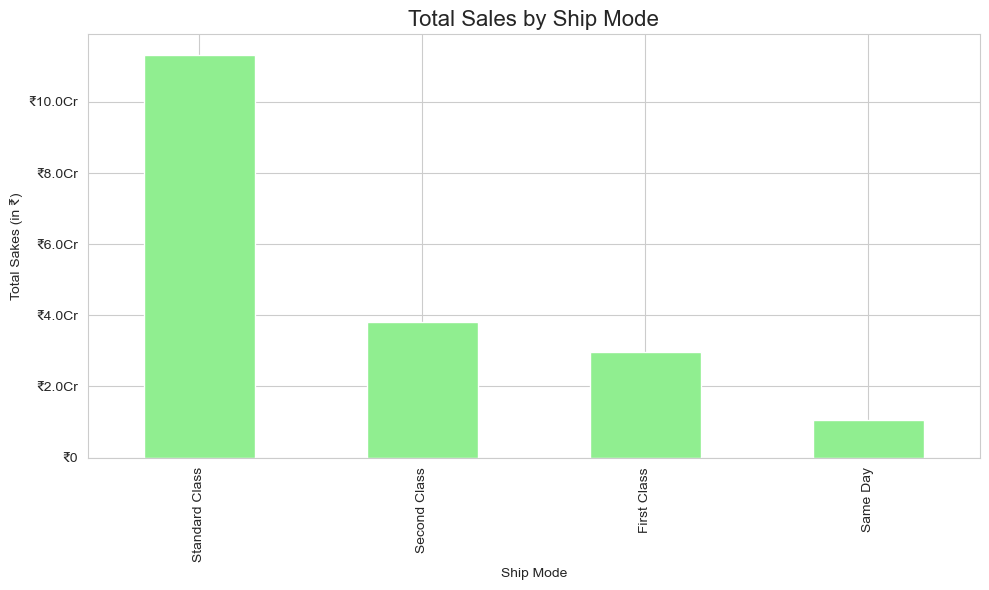

In [81]:
# Total Sales by Ship Mode 

shipmode_sale = df.groupby('Ship Mode')['Sales'].sum().sort_values(ascending = False).head(10)

fig,ax = plt.subplots()
shipmode_sale.plot(kind ='bar' , color = 'lightgreen',ax = ax)
ax.yaxis.set_major_formatter(formatter)
plt.title("Total Sales by Ship Mode", fontsize = 16)
plt.xlabel("Ship Mode")
plt.ylabel('Total Sales (in ₹)')
plt.tight_layout()
plt.show()


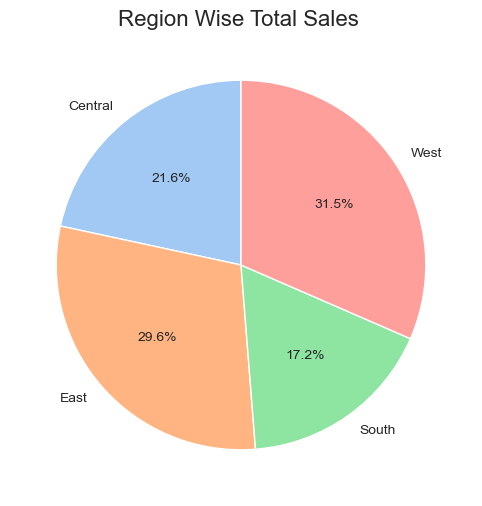

In [96]:
# Region wise Total Sales
regional_sale = df.groupby('Region')['Sales'].sum()

fig, ax = plt.subplots()
colors = sns.color_palette("pastel", 10)
regional_sale.plot(kind ='pie',autopct='%1.1f%%', startangle=90,colors =colors,ax=ax)
plt.title("Region Wise Total Sales ", fontsize = 16)
plt.ylabel('')
plt.show()

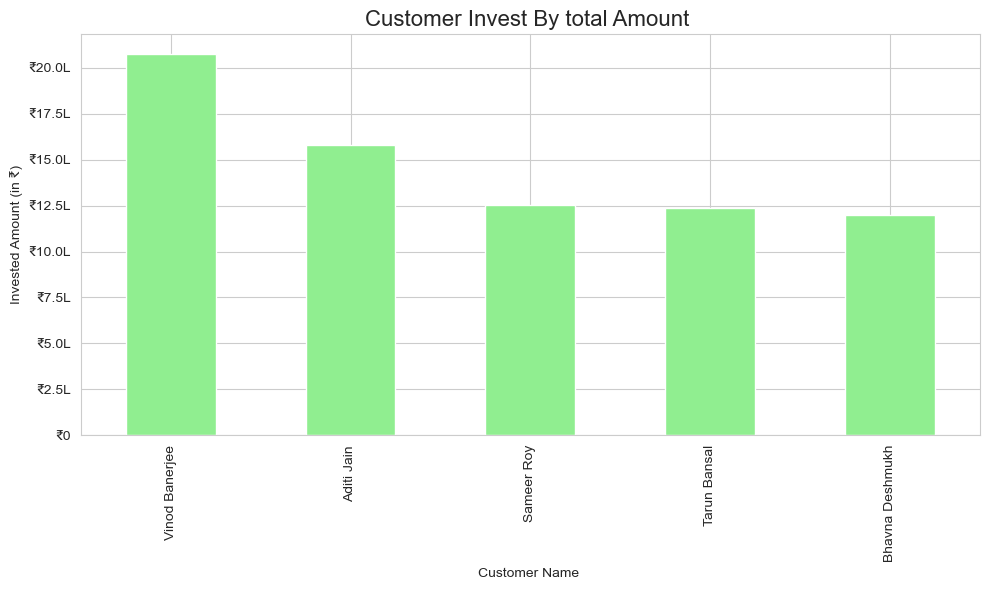

In [126]:
# finding top 5 Customer by order 
customer_sale = df.groupby('Customer Name')['Sales'].sum().sort_values(ascending = False).head(5)

fig, ax = plt.subplots()
customer_sale.plot(kind = 'bar' , color = 'lightgreen',ax = ax)
ax.yaxis.set_major_formatter(formatter)
plt.title("Customer Invest By total Amount ",fontsize = 16)
plt.xlabel('Customer Name ')
plt.ylabel('Invested Amount (in ₹)')
plt.tight_layout()
plt.show()


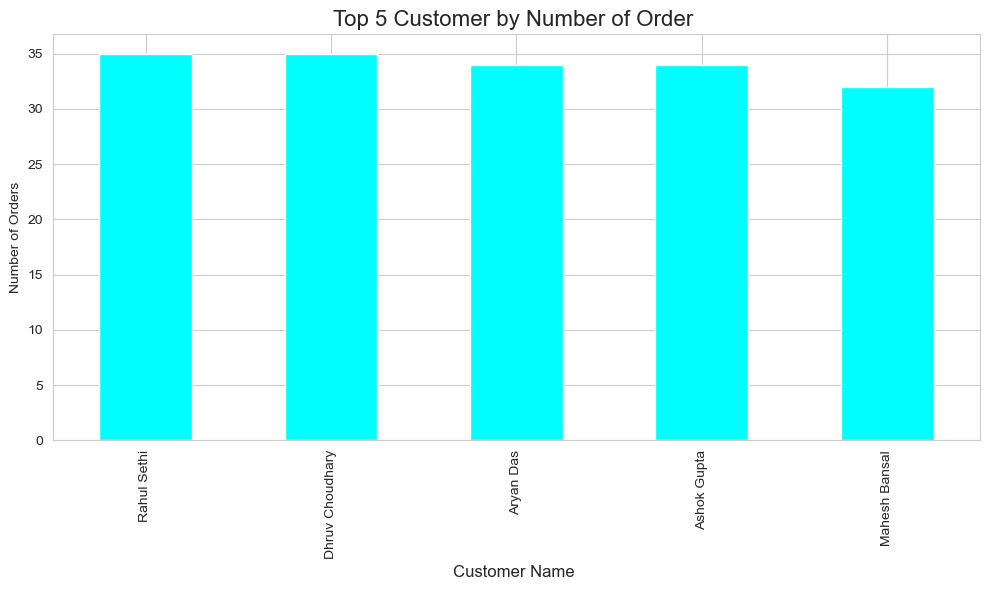

In [141]:
# Top customer by Number of Orders
customer_orders = df.groupby('Customer Name')['Order ID'].count().sort_values(ascending = False).head(5)

fig, ax = plt.subplots()
customer_orders.plot(kind = 'bar' , color = 'cyan',ax = ax)
plt.title("Top 5 Customer by Number of Order ",fontsize = 16)
plt.xlabel('Customer Name ',fontsize = 12)
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.show()

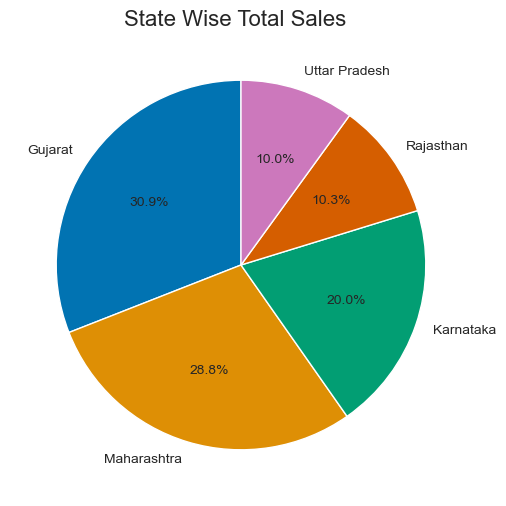

In [157]:
state_wise_sale = df.groupby('State')['Sales'].sum().sort_values(ascending = False).head(5)

fig, ax = plt.subplots()
colors = sns.color_palette("colorblind", 10)
state_wise_sale.plot(kind ='pie',autopct='%1.1f%%', startangle=90,colors =colors,ax=ax)
plt.title("State Wise Total Sales  ", fontsize = 16 )
plt.ylabel('')
plt.show()